## <span style='text-decoration: double underline;color:rgb(10,110,217)'>**Results Model 110**</span>

**Loss function configuration:**

$\lambda_{init} = 1$  
$\lambda_{phys} = 1$  
$\lambda_{bin} = 0$

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
sys.path.append('../')

In [3]:
import utils.evaluation_tools as eval_tools


delta = 1 
shape = (25,25)
model_name = 'ClassicDiffGoL'
parent_folder = '../Data'
seed2plot = 221
seeds = [221, 502, 700, 1204, 3340, 4501, 6054, 6621,8421, 15678, 19302, 38475, 77293, 91827, 99100]  

threshold = 0.5
figsize = (12,9)
subplots_grid = (3,3)
suptitle = 'ClassicDiffGoL Model'

th_ranges = [(0.45, 0.55), (0.40, 0.60), (0.35, 0.65)]

train_history_paths = eval_tools.get_paths_results('train_history.csv', parent_folder, seeds, shape, delta, model_name)
predictions_paths = eval_tools.get_paths_results('predictions.csv', parent_folder, seeds, shape, delta, model_name)
test_results_paths = eval_tools.get_paths_results('test_results.csv', parent_folder, seeds, shape, delta, model_name)
test_data = eval_tools.get_paths_results('test.npz', parent_folder, seeds, shape, delta, model_name)

### <span style='color:rgb(10,110,217)'><u>**Train Results**</u></span>

--- Metrics computed during execution ---
loss: 0.2715 ± 0.0012
val_loss: 0.2733 ± 0.0013


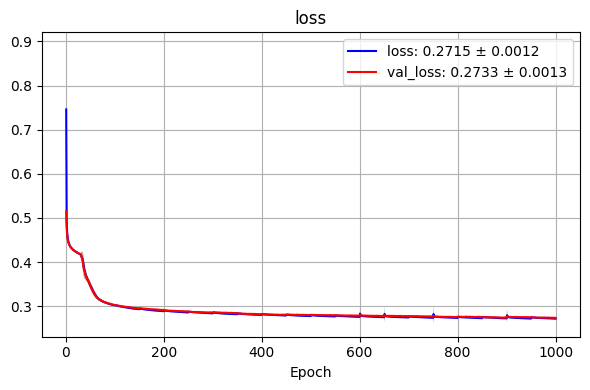

In [4]:
cols2omit = 1
num_rows = 1
eval_tools.display_results(train_history_paths, 'val_', cols2omit, num_rows, True, True)

### <span style='color:rgb(10,110,217)'><u>**Test Results**</u></span>

In [5]:
# Test:
eval_tools.display_results(test_results_paths, '_fin', display_plot=False)

--- Metrics computed during execution ---
Accuracy_init: 0.8648 ± 0.0007
Accuracy_fin: 0.9123 ± 0.0015
Recall_init: 0.5619 ± 0.0030
Recall_fin: 0.5649 ± 0.0071
Specificity_init: 0.9439 ± 0.0005
Specificity_fin: 0.9988 ± 0.0001
Precision_init: 0.7234 ± 0.0020
Precision_fin: 0.9918 ± 0.0005
F1Score_init: 0.6325 ± 0.0024
F1Score_fin: 0.7198 ± 0.0058


--- Results Initial States (15 seeds) ---
Density (true): 20.71% ± 8.76%
Density (pred): 27.25% ± 6.84%
Error/seed:     6.54% ± 0.25%
Max value predicted: 0.9999
HUC% (0.45, 0.55): 4.13% ± 0.05%
HUC% (0.4, 0.6): 8.65% ± 0.09%
HUC% (0.35, 0.65): 13.69% ± 0.14%
Fuzziness Index: 0.5445 ± 0.0978
MSE (prob):0.1091 ± 0.0524
MSE (bin):0.1352 ± 0.0789
MSE (all-zero): 0.2071 ± 0.0876
Wasserstein (EMD): 2.2482 ± 0.0591


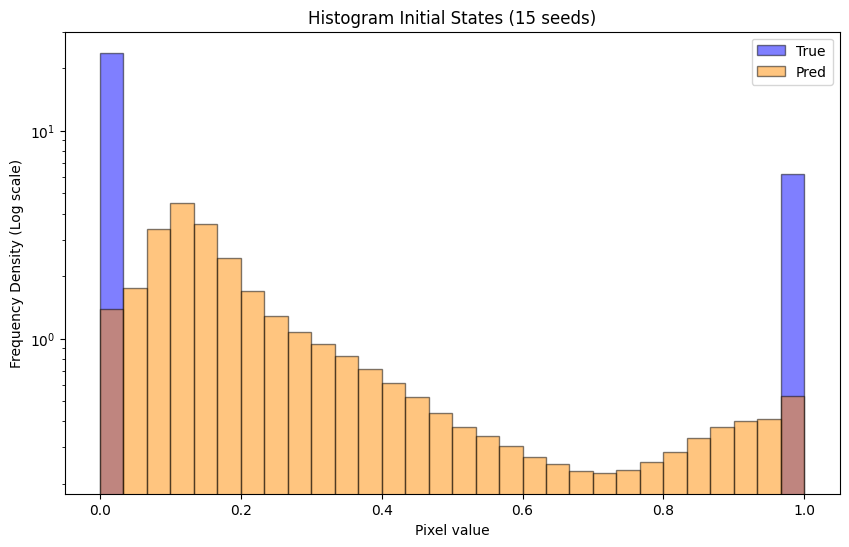

In [6]:
eval_tools.compute_metrics(predictions_paths, test_data,shape,'init', th_ranges, threshold, colors=['blue', 'darkorange'])

--- Results Final States (15 seeds) ---
Density (true): 19.93% ± 8.62%
Density (pred): 11.48% ± 4.02%
Error/seed:     8.46% ± 0.08%
Max value predicted: 0.9999
HUC% (0.45, 0.55): 2.99% ± 0.06%
HUC% (0.4, 0.6): 5.93% ± 0.09%
HUC% (0.35, 0.65): 8.72% ± 0.10%
Fuzziness Index: 0.1759 ± 0.0884
MSE (prob):0.0537 ± 0.0339
MSE (bin):0.0877 ± 0.0583
MSE (all-zero): 0.1993 ± 0.0862
Wasserstein (EMD): 1.6070 ± 0.0069


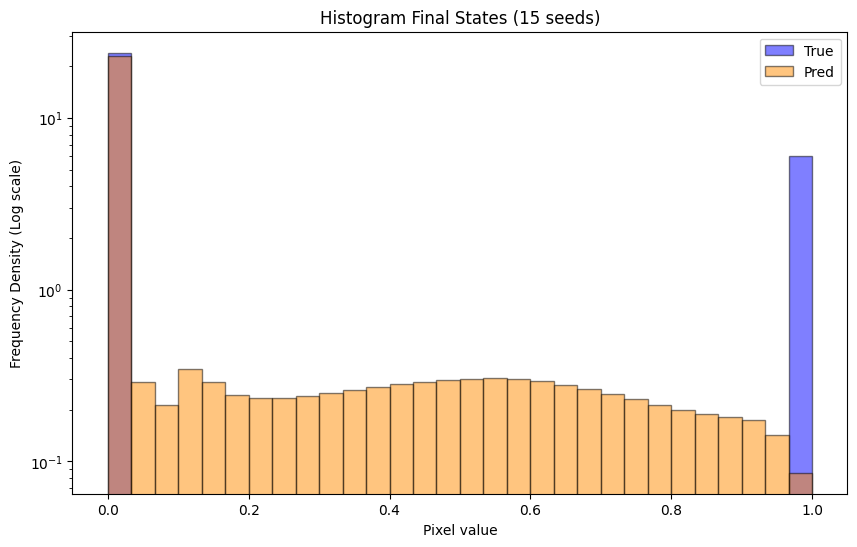

In [7]:
eval_tools.compute_metrics(predictions_paths, test_data,shape,'fin', th_ranges, threshold, colors=['blue', 'darkorange'])

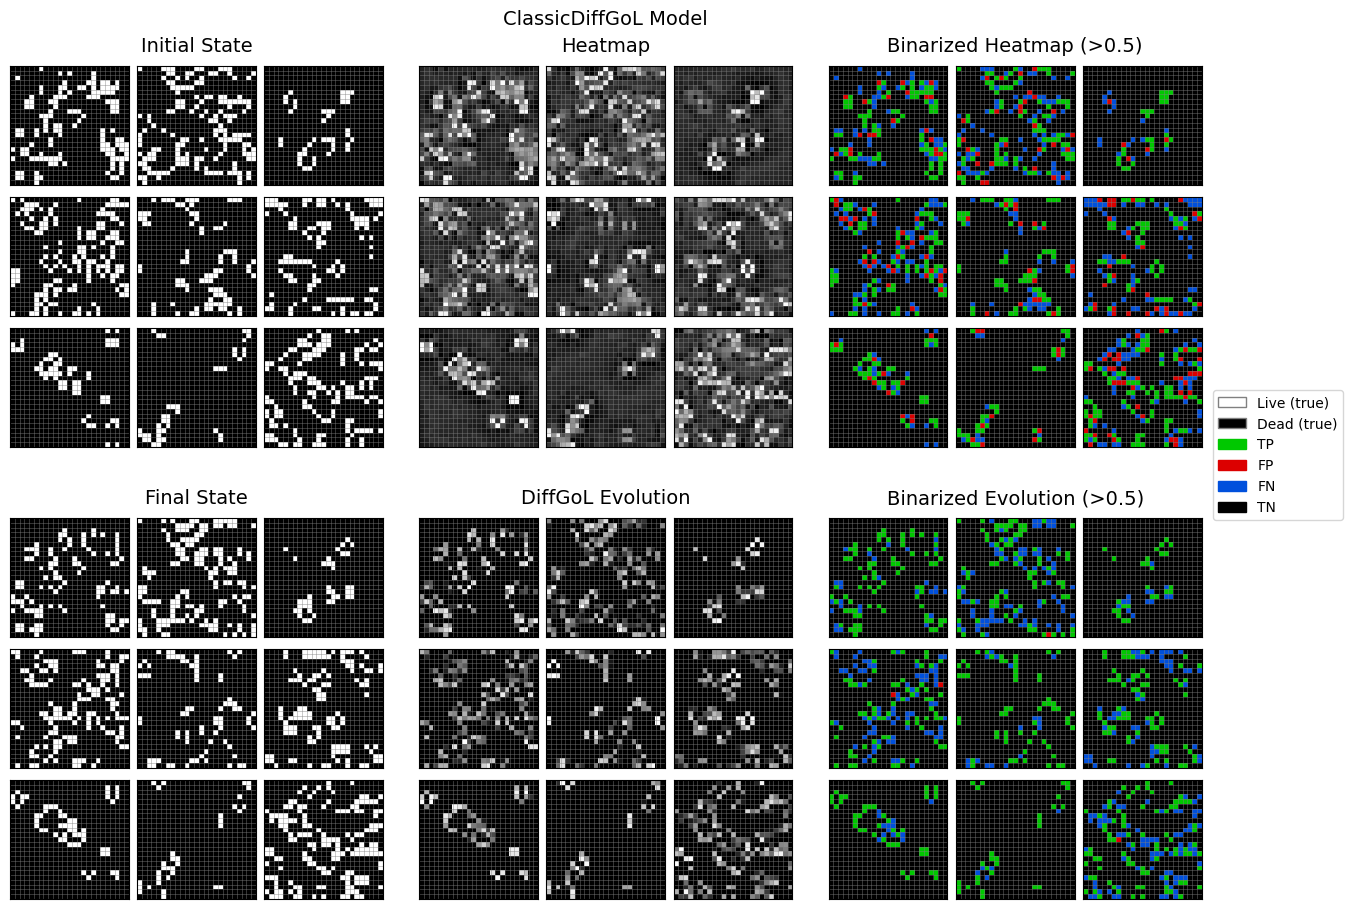

In [8]:
file_test = test_data[seed2plot]
file_pred = predictions_paths[seed2plot]
titles = ['Initial State', 'Heatmap', f'Binarized Heatmap (>{threshold})', 
          'Final State', 'DiffGoL Evolution', f'Binarized Evolution (>{threshold})']
eval_tools.display_states(file_pred, file_test, shape, threshold, titles, subplots_grid, suptitle, figsize, random=False)